In [2]:
import torch
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments, ViTImageProcessor, BertTokenizer, VisionEncoderDecoderModel

import torch
from torch.utils.data import Dataset
import os
import cv2
import numpy as np

from PIL import Image, ImageFile
from tqdm import tqdm
import xml.etree.ElementTree as ET


import re

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from plant_dataset import load_sideview_images
from image_process import process_leaf_image
from plant_tokenizer import vec2token, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, VOCAB_SIZE
from string_to_xml_to_vec import xml2vec, linked_to_recursive
from plant_dataset import PlantDataset


device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"

Quantize Paramter in 199 levels


In [3]:
from models.model import PlantArchitectureModel
from transformers import VisionEncoderDecoderModel, BertConfig, BertModel, ViTModel, AutoConfig, GPT2Config, AutoImageProcessor

# 1. Define decoder configuration
decoder_checkpoint = "gpt2-medium"
decoder_config = GPT2Config.from_pretrained(decoder_checkpoint)
decoder_config.max_position_embeddings = 4096*2 # Set maximum sequence length
decoder_config.vocab_size = VOCAB_SIZE  # Match with tokenizer's vocabulary size
decoder_config.add_cross_attention=True
decoder_config.is_decoder=True

encoder_checkpoint = "facebook/dinov2-small"
image_size = 448
encoder_config = AutoConfig.from_pretrained(encoder_checkpoint)
if 0:
    image_processor = AutoImageProcessor.from_pretrained(encoder_checkpoint)
    image_processor.crop_size['width'] = image_size
    image_processor.crop_size['height'] = image_size
    image_processor.size['shortest_edge'] = image_size
else:
    image_processor = None

model = PlantArchitectureModel.from_encoder_decoder_pretrained(
    encoder_checkpoint, decoder_checkpoint, 
    decoder_config=decoder_config, 
    encoder_config=encoder_config,
    decoder_ignore_mismatched_sizes=True,
    use_depth=True,
    torch_dtype=torch.float16, 
)

Quantize Paramter in 199 levels


Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2-medium and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.

Total 400000 images and plant strings loaded


[W717 18:28:56.622702010 NNPACK.cpp:61] Could not initialize NNPACK! Reason: Unsupported hardware.


[184 184 184 184]


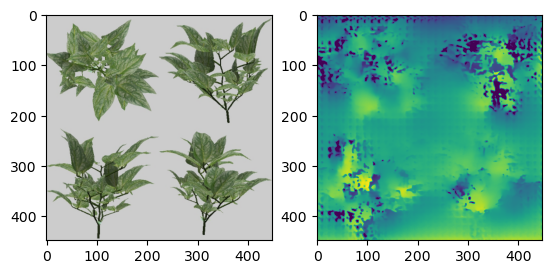

In [4]:
import matplotlib.pyplot as plt

dataset_path = "/home/lion397/datasets/GEMINI/plant_architecture/20250311_Sideview_40Days"

dataset = PlantDataset(root_dir=dataset_path, 
                       process_leaf=True, image_size=image_size,
                       side_view=True,
                       mode='train',
                       preload=False, add_sos_token=False,
                       flip_test=True)
   
ind = 20
pixel_values = dataset[ind]["pixel_values"].unsqueeze(0).to(model.device)
plant_info = dataset[ind]["plant_info"]
plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens

image_vis = pixel_values.squeeze().permute(1,2,0).cpu().numpy()
# image_vis = cv2.cvtColor(image_vis,cv2.COLOR_RGB2BGR)
# image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(image_vis)

depth = model.estimate_depth(pixel_values)
# generated_ids = model.generate(pixel_values,
#                             decoder_start_token_id=SOS_TOKEN,
#                             decoder_input_ids=plant_info,
#                             eos_token_id=EOS_TOKEN,
#                             pad_token_id=PAD_TOKEN,
#                             max_length=2500
#                             )
# print(generated_ids)
depth_vis = depth[0,0,:,:].cpu().numpy()
plt.subplot(1,2,2)
plt.imshow(depth_vis)

# Test run
with torch.no_grad():
    result = model.generate(pixel_values,
                            decoder_start_token_id=SOS_TOKEN,
                            decoder_input_ids=plant_info,
                            eos_token_id=EOS_TOKEN,
                            pad_token_id=PAD_TOKEN,
                            # do_sample=True,
                            # num_beams=5,
                            max_length=10,
                            use_cache=True
                            )
    result = result.squeeze().cpu().numpy()[6:]

print(result)

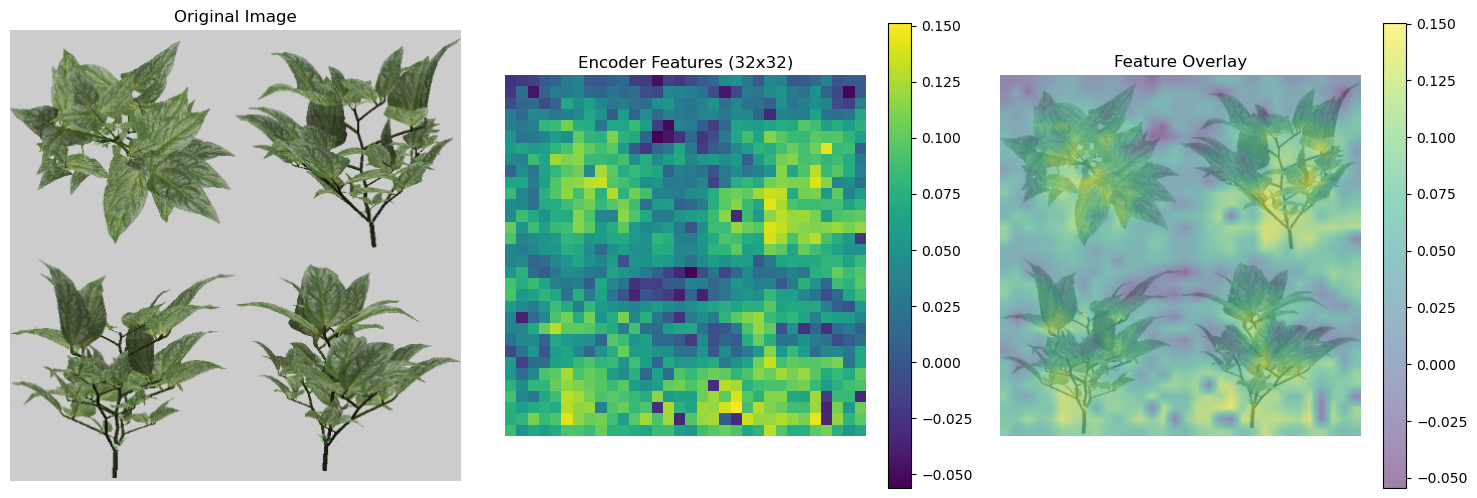

Encoder output shape: torch.Size([1, 1025, 384])
Number of patches: 32x32
Feature dimension: 384
Feature map range: [-0.056, 0.151]


In [5]:
image_processor = AutoImageProcessor.from_pretrained(encoder_checkpoint)
image_processor.crop_size['width'] = image_size
image_processor.crop_size['height'] = image_size
image_processor.size['shortest_edge'] = image_size

# Extract encoder features and visualize them
with torch.no_grad():
    # Get encoder outputs
    if 1:
        input_image = image_processor(pixel_values, return_tensors="pt").pixel_values
        encoder_outputs = model.encoder(input_image)
    else:
        depth = model.estimate_depth(pixel_values)
        encoder_outputs = model.encoder(depth)
    encoder_features = encoder_outputs.last_hidden_state  # Shape: [batch_size, seq_len, hidden_dim]
    
    # Remove batch dimension and get patch features (excluding CLS token if present)
    features = encoder_features.squeeze(0)  # Shape: [seq_len, hidden_dim]
    
    # For ViT models, the sequence includes patch tokens and possibly a CLS token
    # Typically the last token is CLS, so we exclude it
    patch_features = features[:-1]  # Exclude CLS token, Shape: [num_patches, hidden_dim]
    
    # Calculate number of patches per dimension
    num_patches = int(np.sqrt(patch_features.shape[0]))
    
    # Aggregate features across the hidden dimension (mean, max, or specific channels)
    # Option 1: Mean across all feature dimensions
    feature_map = patch_features.mean(dim=1)  # Shape: [num_patches]
    
    # Option 2: Use first few feature dimensions
    # feature_map = patch_features[:, :3].mean(dim=1)  # Use first 3 dimensions
    
    # Reshape to spatial dimensions
    feature_map = feature_map.reshape(num_patches, num_patches).cpu().numpy()
    
    # Resize to match input image size for overlay
    feature_map_resized = cv2.resize(feature_map, (image_vis.shape[1], image_vis.shape[0]))

# Visualize the features
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(image_vis[:,:,:3])  # Show RGB channels only
plt.title("Original Image")
plt.axis('off')

# Feature map
plt.subplot(1, 3, 2)
plt.imshow(feature_map, cmap='viridis')
plt.title(f"Encoder Features ({num_patches}x{num_patches})")
plt.colorbar()
plt.axis('off')

# Overlay feature map on original image
plt.subplot(1, 3, 3)
plt.imshow(image_vis[:,:,:3], alpha=0.7)
plt.imshow(feature_map_resized, alpha=0.5, cmap='viridis')
plt.title("Feature Overlay")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

# Print feature statistics
print(f"Encoder output shape: {encoder_features.shape}")
print(f"Number of patches: {num_patches}x{num_patches}")
print(f"Feature dimension: {patch_features.shape[1]}")
print(f"Feature map range: [{feature_map.min():.3f}, {feature_map.max():.3f}]")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


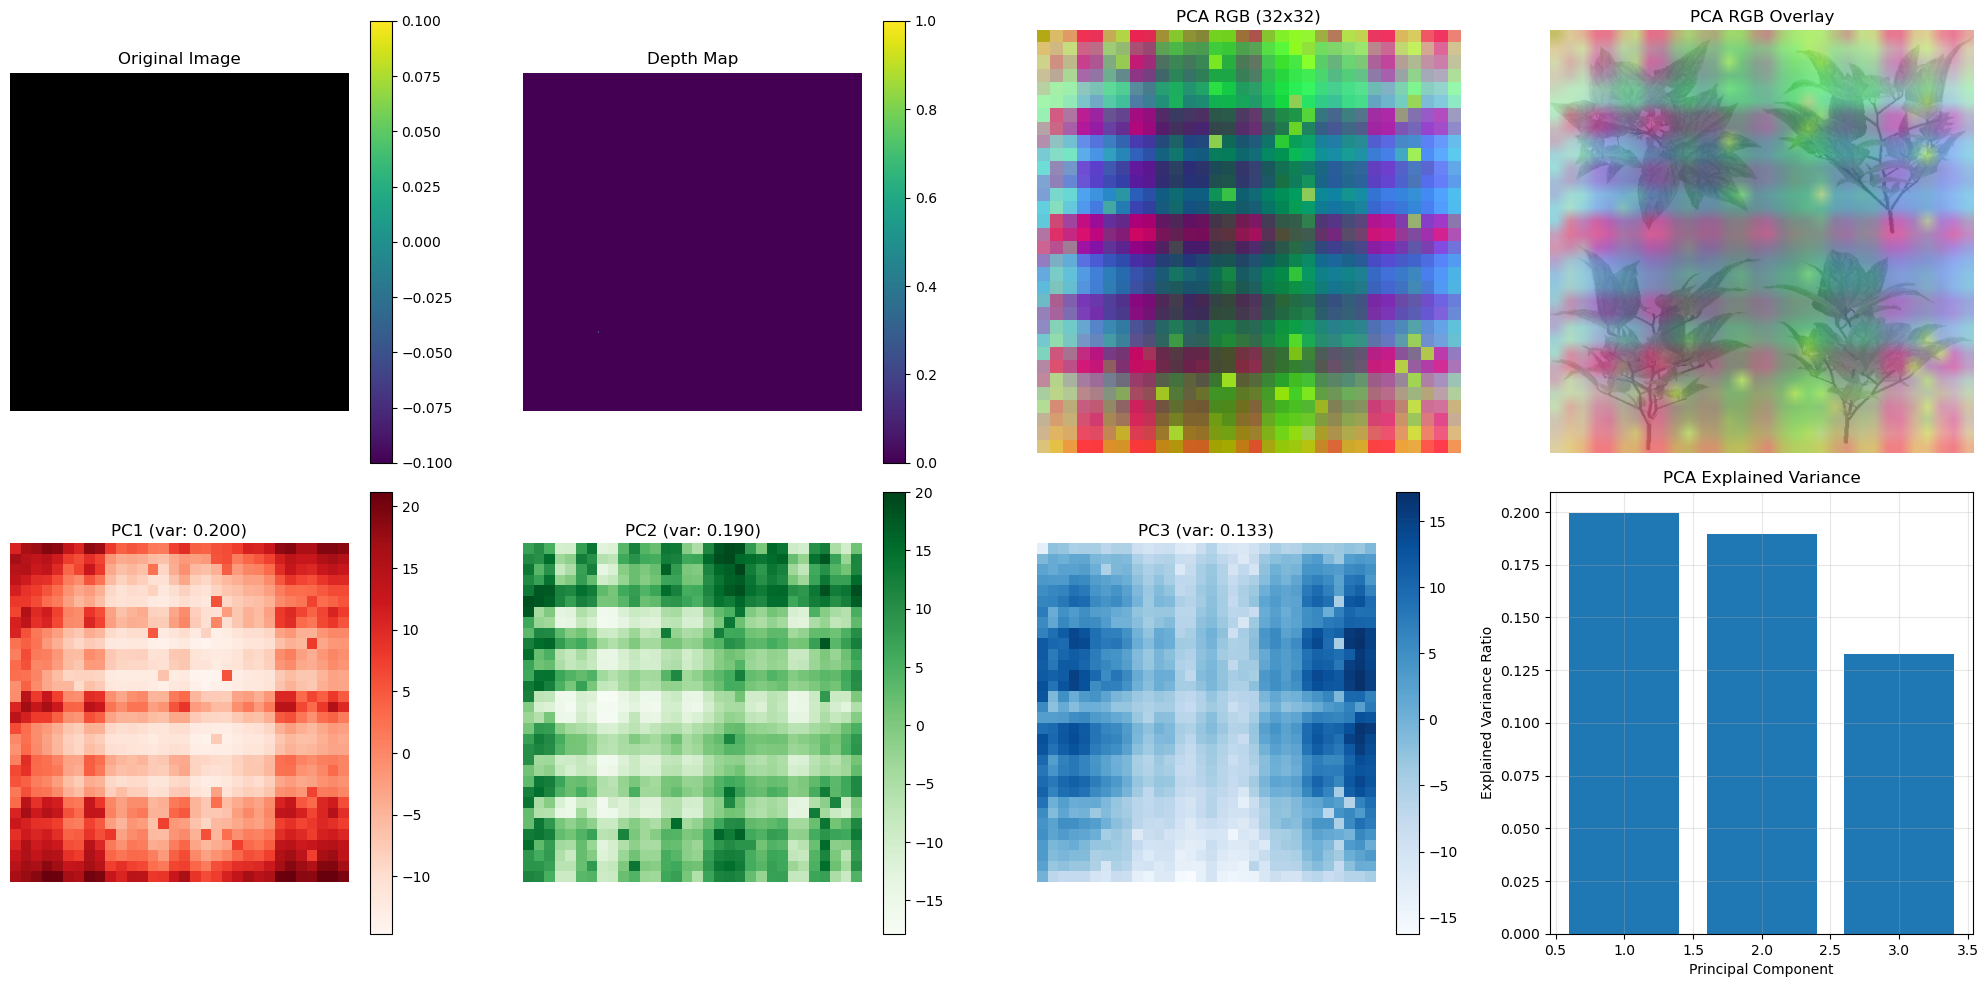

Original feature dimension: 384
PCA explained variance ratio: [0.19967581 0.18953443 0.1327862 ]
Total variance explained: 0.522
PCA components shape: (1024, 3)
PCA RGB range: R[0.000, 1.000], G[0.000, 1.000], B[0.000, 1.000]


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Run PCA on encoder features
with torch.no_grad():
    # Get encoder outputs (using the same logic as above)
    if 0:
        if 1:
            input_image = image_processor(pixel_values, return_tensors="pt").pixel_values
        else:
            input_image = pixel_values
    else:
        depth = model.estimate_depth(pixel_values)
        depth = depth.cpu().numpy().astype(np.uint8)
        if 1:
            
            input_image = image_processor(depth, return_tensors="pt").pixel_values
        else:
            input_image = depth
            
    encoder_outputs = model.encoder(input_image)

    encoder_features = encoder_outputs.last_hidden_state  # Shape: [batch_size, seq_len, hidden_dim]
    
    # Remove batch dimension and get patch features (excluding CLS token if present)
    features = encoder_features.squeeze(0)  # Shape: [seq_len, hidden_dim]
    patch_features = features[:-1]  # Exclude CLS token, Shape: [num_patches, hidden_dim]
    
    # Calculate number of patches per dimension
    num_patches = int(np.sqrt(patch_features.shape[0]))
    
    # Convert to numpy for PCA
    features_np = patch_features.cpu().numpy()  # Shape: [num_patches, hidden_dim]
    
    # Standardize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_np)
    
    # Apply PCA
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(features_scaled)  # Shape: [num_patches, 3]
    
    # Normalize PCA components to [0, 1] for RGB visualization
    pca_rgb = np.zeros_like(pca_features)
    for i in range(3):
        pca_rgb[:, i] = (pca_features[:, i] - pca_features[:, i].min()) / (pca_features[:, i].max() - pca_features[:, i].min())
    
    # Reshape to spatial dimensions
    pca_rgb_map = pca_rgb.reshape(num_patches, num_patches, 3)
    
    # Resize to match input image size
    pca_rgb_resized = cv2.resize(pca_rgb_map, (image_vis.shape[1], image_vis.shape[0]))

# Visualize PCA results
plt.figure(figsize=(20, 10))

# Original image
plt.subplot(2, 4, 1)
plt.imshow(input_image.squeeze().permute(1,2,0), cmap='viridis')
plt.title("Original Image")
plt.colorbar()
plt.axis('off')

# Depth image
plt.subplot(2, 4, 2)
depth_vis = depth[0,0,:,:]
plt.imshow(depth_vis, cmap='viridis')
plt.title("Depth Map")
plt.colorbar()
plt.axis('off')

# PCA RGB visualization
plt.subplot(2, 4, 3)
plt.imshow(pca_rgb_map)
plt.title(f"PCA RGB ({num_patches}x{num_patches})")
plt.axis('off')

# PCA RGB overlay on original image
plt.subplot(2, 4, 4)
plt.imshow(image_vis[:,:,:3], alpha=0.6)
plt.imshow(pca_rgb_resized, alpha=0.6)
plt.title("PCA RGB Overlay")
plt.axis('off')

# Individual PCA components
for i in range(3):
    plt.subplot(2, 4, 5 + i)
    component_map = pca_features[:, i].reshape(num_patches, num_patches)
    plt.imshow(component_map, cmap=['Reds', 'Greens', 'Blues'][i])
    plt.title(f"PC{i+1} (var: {pca.explained_variance_ratio_[i]:.3f})")
    plt.colorbar()
    plt.axis('off')

# PCA explained variance
plt.subplot(2, 4, 8)
plt.bar(range(1, 4), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print PCA statistics
print(f"Original feature dimension: {features_np.shape[1]}")
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")
print(f"PCA components shape: {pca_features.shape}")
print(f"PCA RGB range: R[{pca_rgb[:, 0].min():.3f}, {pca_rgb[:, 0].max():.3f}], "
      f"G[{pca_rgb[:, 1].min():.3f}, {pca_rgb[:, 1].max():.3f}], "
      f"B[{pca_rgb[:, 2].min():.3f}, {pca_rgb[:, 2].max():.3f}]")

In [3]:
# Test tokenizer
from transformers import AutoModelForCausalLM, AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2-medium")


dataset_path = "/home/lion397/datasets/GEMINI/plant_architecture/20250311_Sideview_40Days"

dataset = PlantDataset(root_dir=dataset_path, 
                       process_leaf=True, image_size=448,
                       side_view=True,
                       mode='train',
                       preload=False, add_sos_token=False,
                       flip_test=True)

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Total 400000 images and plant strings loaded


In [4]:
ind = -1
#pixel_values = dataset[ind]["pixel_values"].unsqueeze(0).to(model.device)
labels = dataset[ind]["labels"]
#plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens

labels_str = " ".join(map(str, labels))
print(labels_str)
inputs = tokenizer(labels_str, 
                   max_length=4096*2,
                   truncation=True,
                   return_tensors="pt")

print(inputs)
print(len(labels))
print(len(inputs[0]))

224 71 73 72 224 0 81 205 153 94 77 1 61 55 40 151 2 41 44 108 115 77 3 60 37 40 34 6 94 84 114 94 79 7 61 53 86 142 8 64 51 102 105 76 9 68 100 82 34 10 68 88 40 34 11 68 87 36 34 12 102 86 114 94 79 13 61 51 86 139 14 66 51 99 140 76 15 67 92 82 34 16 68 97 40 34 17 67 83 36 34 13 61 51 86 149 14 64 50 99 141 76 15 65 122 82 34 16 65 96 40 34 17 65 88 36 34 13 61 51 86 157 14 62 49 101 157 76 15 62 101 82 34 16 62 104 40 34 17 62 104 36 34 13 61 51 86 136 14 65 51 98 152 76 15 68 96 82 34 16 68 99 40 34 17 68 95 36 34 13 61 51 86 164 14 64 51 101 109 76 15 68 104 82 34 16 68 95 40 34 17 68 97 36 34 13 61 51 86 146 14 63 50 100 115 76 15 65 101 82 34 16 66 106 40 34 17 65 88 36 34 13 60 51 86 155 14 63 50 99 98 76 15 65 86 82 34 16 65 93 40 34 17 65 95 36 34 13 60 51 86 150 14 62 50 99 145 76 15 63 98 82 34 16 64 97 40 34 17 63 91 36 34 13 59 50 86 153 14 62 50 100 145 76 15 64 94 82 34 16 65 88 40 34 17 64 101 36 34 13 57 50 86 139 14 60 46 96 114 76 15 61 91 82 34 16 62 85 40 34 17 

In [ ]:
outputs = tokenizer.decode(inputs['input_ids'][0])  # Extract first (and only) sequence
print(outputs)

224 71 73 72 224 0 81 205 153 94 77 1 61 55 40 151 2 41 44 108 115 77 3 60 37 40 34 6 94 84 114 94 79 7 61 53 86 142 8 64 51 102 105 76 9 68 100 82 34 10 68 88 40 34 11 68 87 36 34 12 102 86 114 94 79 13 61 51 86 139 14 66 51 99 140 76 15 67 92 82 34 16 68 97 40 34 17 67 83 36 34 13 61 51 86 149 14 64 50 99 141 76 15 65 122 82 34 16 65 96 40 34 17 65 88 36 34 13 61 51 86 157 14 62 49 101 157 76 15 62 101 82 34 16 62 104 40 34 17 62 104 36 34 13 61 51 86 136 14 65 51 98 152 76 15 68 96 82 34 16 68 99 40 34 17 68 95 36 34 13 61 51 86 164 14 64 51 101 109 76 15 68 104 82 34 16 68 95 40 34 17 68 97 36 34 13 61 51 86 146 14 63 50 100 115 76 15 65 101 82 34 16 66 106 40 34 17 65 88 36 34 13 60 51 86 155 14 63 50 99 98 76 15 65 86 82 34 16 65 93 40 34 17 65 95 36 34 13 60 51 86 150 14 62 50 99 145 76 15 63 98 82 34 16 64 97 40 34 17 63 91 36 34 13 59 50 86 153 14 62 50 100 145 76 15 64 94 82 34 16 65 88 40 34 17 64 101 36 34 13 57 50 86 139 14 60 46 96 114 76 15 61 91 82 34 16 62 85 40 34 17 

In [ ]:
if outputs == inputs:
    print("Two strings are the same")
else:
    print("Two strings are the differnt")

Two strings are the differnt


In [8]:
ind = -1

plant_vec = dataset[ind]["plant_vec"]
plant_vec_cat = np.concatenate(plant_vec)
plant_vec_str = " ".join(map(str, plant_vec_cat))
print(plant_vec_str)
inputs = tokenizer(plant_vec_str, 
                   max_length=4096*2,
                   truncation=True,
                   return_tensors="pt")

print(inputs)
print(len(labels))
print(len(inputs[0]))

0.0 0.0 7.24495 317.285 187.312 39.0 1.0 0.0 1.0 0.03 0.00624496 0.0 182.396 0.0 2.0 0.0001 0.0004 75.7229 92.6681 1.0 0.0 3.0 0.02 -6.26843 0.0 -15.0 1.0 0.0 40.0 14.0113 90.0 39.0 3.0 1.0 1.0 0.025 0.00439149 20.0 160.081 1.0 2.0 0.0633485 0.0018 59.6708 66.3213 0.9 1.0 3.0 0.106645 54.7562 10.0 -15.0 1.0 4.0 0.118495 24.1735 0.0 -15.0 1.0 5.0 0.106645 23.3455 -10.0 -15.0 2.0 0.0 59.268 19.3157 90.0 39.0 3.0 2.0 1.0 0.025 0.00235094 20.0 151.928 2.0 2.0 0.0759413 0.0018 51.4284 154.952 0.9 2.0 3.0 0.0869778 34.7736 10.0 -15.0 2.0 4.0 0.096642 47.002 0.0 -15.0 2.0 5.0 0.0869778 12.4071 -10.0 -15.0 2.0 1.0 0.025 0.00225644 20.0 178.255 2.0 2.0 0.0567685 0.00140954 52.8205 157.79 0.9 2.0 3.0 0.0656684 111.008 10.0 -15.0 2.0 4.0 0.0729649 45.7395 0.0 -15.0 2.0 5.0 0.0656684 25.0475 -10.0 -15.0 2.0 1.0 0.0250001 0.00216622 20.0 197.59 2.0 2.0 0.0373942 0.000879162 57.3117 197.726 0.9 2.0 3.0 0.0399443 58.4176 10.0 -15.0 2.0 4.0 0.0443825 64.3884 0.0 -15.0 2.0 5.0 0.0399443 64.5525 -10.0 -